In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../fraudTest.csv')

In [7]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [8]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
df.drop(df.columns[0], axis=1, inplace=True)

In [9]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
368755,2020-11-11 01:25:28,4670613943676271,fraud_Kuhic LLC,shopping_net,6.77,Bianca,Novak,F,0953 David Skyway,Cuthbert,GA,39840,31.7706,-84.7936,5726,Fitness centre manager,1947-08-14,3c8f8e51ac23e2963cae881fdb80f803,1384133128,31.326819,-84.284376,0


In [10]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


### Category Column

In [14]:
import pandas as pd

total_counts_by_category = df['category'].value_counts()

fraud_counts_by_category = df.groupby('category')['is_fraud'].sum()

# Step 3: Calculate non-fraudulent transactions
non_fraud_counts_by_category = total_counts_by_category - fraud_counts_by_category

fraud_ratio_by_category = fraud_counts_by_category / total_counts_by_category

# Step 5: Combine the results into a single DataFrame
combined_counts = pd.DataFrame({
    'total_tran': total_counts_by_category,
    'total_frauds': fraud_counts_by_category,
    'fraud_ratio': fraud_ratio_by_category,
    'total_non_frauds': non_fraud_counts_by_category,

}).fillna(0)  # Fill NaN with 0 for categories with no frauds

combined_counts_category_sorted = combined_counts.sort_values(by='total_frauds', ascending=False)

print(combined_counts_category_sorted)


                total_tran  total_frauds  fraud_ratio  total_non_frauds
category                                                               
shopping_net         41779           506     0.012111             41273
grocery_pos          52553           485     0.009229             52068
misc_net             27367           267     0.009756             27100
shopping_pos         49791           213     0.004278             49578
gas_transport        56370           154     0.002732             56216
misc_pos             34574            72     0.002082             34502
personal_care        39327            70     0.001780             39257
home                 52345            67     0.001280             52278
kids_pets            48692            65     0.001335             48627
entertainment        40104            59     0.001471             40045
food_dining          39268            54     0.001375             39214
health_fitness       36674            52     0.001418           

/var/folders/tt/ndzk13v944z9y5c79vdqq_mr0000gp/T/ipykernel_3652/3902720609.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(combined_counts_category_sorted.index, rotation=90)


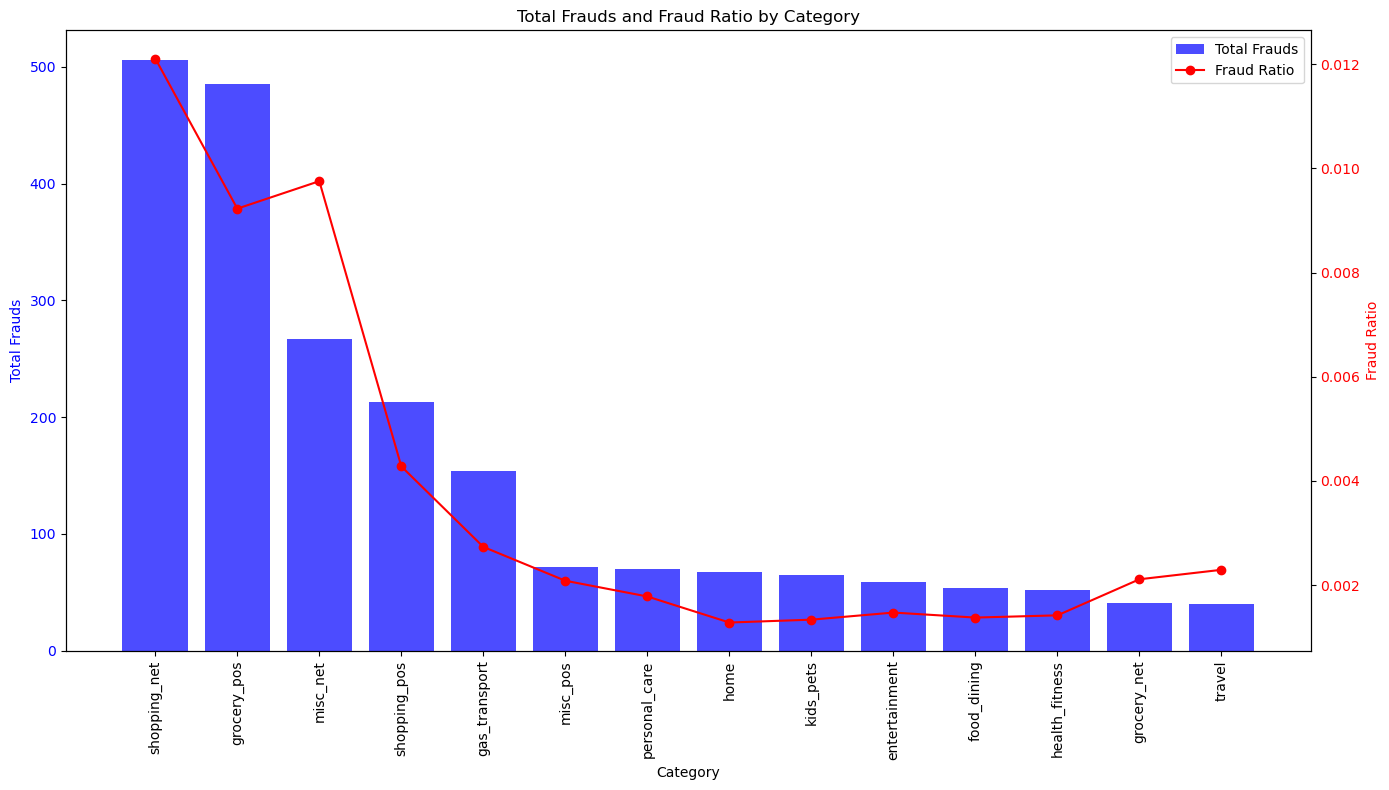

In [44]:
# Plotting the bar graph
fig, ax1 = plt.subplots(figsize=(14, 8))

ax1.bar(combined_counts_category_sorted.index, combined_counts_category_sorted['total_frauds'], color='b', alpha=0.7, label='Total Frauds')
ax1.set_xlabel('Category')
ax1.set_ylabel('Total Frauds', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticklabels(combined_counts_category_sorted.index, rotation=90)

# Create a secondary y-axis for the fraud ratio
ax2 = ax1.twinx()
ax2.plot(combined_counts_category_sorted.index, combined_counts_category_sorted['fraud_ratio'], color='r', marker='o', label='Fraud Ratio')
ax2.set_ylabel('Fraud Ratio', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Title and legend
plt.title('Total Frauds and Fraud Ratio by Category')
fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Show the plot
plt.show()

### Gender

In [38]:
df['gender'].value_counts()

gender
F    304886
M    250833
Name: count, dtype: int64

In [33]:
# Count occurrences of each credit card number
cc_num_counts = df['cc_num'].value_counts()

### credit card that were envolved in fraud (more than 1000 data in dataset)

In [37]:
# Filter credit card numbers with counts greater than or equal to 1000
cc_num_counts_filtered_morethan_1000 = cc_num_counts[cc_num_counts >= 1000]

# Filter the original DataFrame to include only the filtered credit card numbers
filtered_df_morethan_1000 = df[df['cc_num'].isin(cc_num_counts_filtered_morethan_1000.index)]

# Group by 'cc_num' and count 'is_fraud' occurrences
fraud_counts_morethan_1000 = filtered_df_morethan_1000.groupby('cc_num')['is_fraud'].sum()

# Filter fraud counts to display only where fraud count is at least 1
fraud_counts_filtered_morethan_1000 = fraud_counts_morethan_1000[fraud_counts_morethan_1000 >= 1]

# Calculate the total sum of fraudulent transactions
total_fraud_sum_morethan_1000 = fraud_counts_filtered_morethan_1000.sum()

# Print the results
# print("Credit card numbers with at least 1 fraudulent transaction:")
# print(fraud_counts_filtered_morethan_1000)

print("\nTotal sum of fraudulent transactions:")
print(total_fraud_sum_morethan_1000)



Total sum of fraudulent transactions:
312


### credit card that were envolved in fraud (less than 1000 data in dataset)

In [36]:
# Filter credit card numbers with counts greater than or equal to 1000
cc_num_counts_filtered_lessthan_1000 = cc_num_counts[cc_num_counts < 1000]

# Filter the original DataFrame to include only the filtered credit card numbers
filtered_df_lessthan_1000 = df[df['cc_num'].isin(cc_num_counts_filtered_lessthan_1000.index)]

# Group by 'cc_num' and count 'is_fraud' occurrences
fraud_counts_lessthan_1000 = filtered_df_lessthan_1000.groupby('cc_num')['is_fraud'].sum()

# Filter fraud counts to display only where fraud count is at least 1
fraud_counts_filtered_lessthan_1000= fraud_counts_lessthan_1000[fraud_counts_lessthan_1000 >= 1]

# Calculate the total sum of fraudulent transactions
total_fraud_sum_lessthan_1000 = fraud_counts_filtered_lessthan_1000.sum()

# Print the results
# print("Credit card numbers with at least 1 fraudulent transaction:")
# print(fraud_counts_filtered_lessthan_1000)

print("\nTotal sum of fraudulent transactions:")
print(total_fraud_sum_lessthan_1000)


Total sum of fraudulent transactions:
1833


In [11]:
df[['is_fraud']].value_counts()

is_fraud
0           553574
1             2145
Name: count, dtype: int64

In [39]:
df.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [40]:
duplicates = df[df.duplicated()]
duplicates

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


In [45]:
df.dtypes

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

## Data and Time Series

In [46]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [57]:
df['dob'] = pd.to_datetime(df['dob'])

In [58]:
df['dob'].isna().sum()

0

In [79]:
df['year'] = df['trans_date_trans_time'].dt.year
df['month'] = df['trans_date_trans_time'].dt.month
df['day'] = df['trans_date_trans_time'].dt.day
df['time'] = df['trans_date_trans_time'].dt.time

In [80]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
393806,2020-11-22 22:33:25,36485887555770,"fraud_Berge, Kautzer and Harris",personal_care,3.29,Michael,Gross,M,230 Ryan Tunnel Apt. 025,Fulton,OH,43321,40.4971,-82.8342,267,Facilities manager,2005-01-29,ed3a542009029c01d7d4a673fc89558c,1385159605,40.037832,-81.969933,0,2020,11,22,22:33:25


In [56]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,2020,6,21,12:14:25
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,2020,6,21,12:14:33
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,2020,6,21,12:14:53
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,2020,6,21,12:15:15
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,2020,6,21,12:15:17


In [54]:
df['month'].value_counts()

month
12    139538
8      88759
7      85848
11     72635
9      69533
10     69348
6      30058
Name: count, dtype: int64

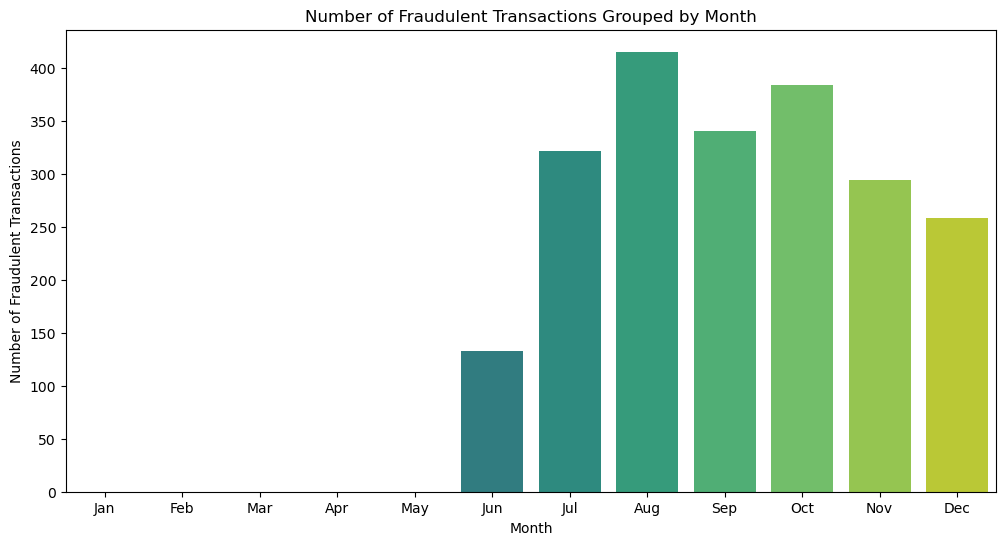

In [61]:
# Filter only fraudulent transactions
fraud_df = df[df['is_fraud'] == 1]

# Group by month and count the transactions
monthly_fraud_transactions = fraud_df.groupby('month').size().reset_index(name='fraud_transaction_count')

# Create a complete set of months (from 1 to 12)
all_months = pd.DataFrame({'month': range(1, 13)})

# Merge with the actual data to fill missing months
monthly_fraud_transactions = all_months.merge(monthly_fraud_transactions, on='month', how='left').fillna(0)

# Map month numbers to month names
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_fraud_transactions['month'] = monthly_fraud_transactions['month'].map(month_names)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_fraud_transactions, x='month', y='fraud_transaction_count', palette='viridis')

plt.title('Number of Fraudulent Transactions Grouped by Month')
plt.xlabel('Month')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

In [86]:
df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')

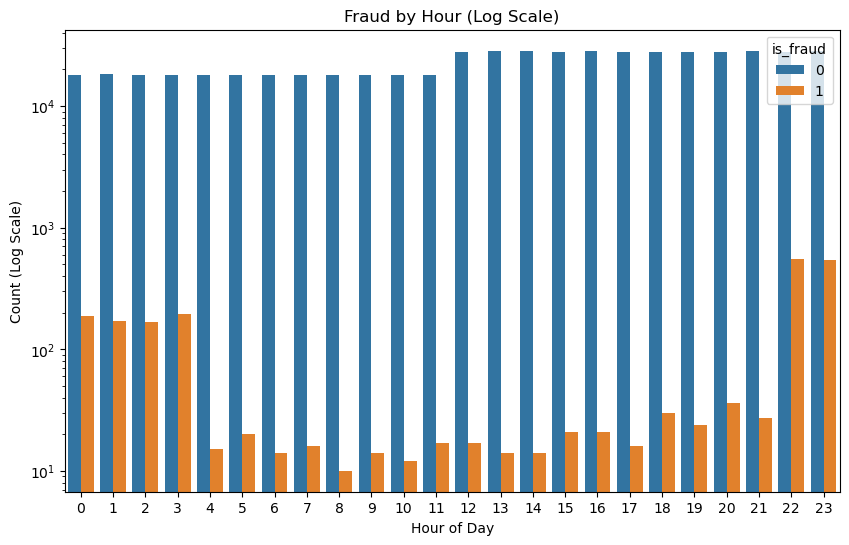

In [91]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=df['time'].dt.hour, hue=df['is_fraud'])
ax.set_yscale('log')
plt.title('Fraud by Hour (Log Scale)')
plt.xlabel('Hour of Day')
plt.ylabel('Count (Log Scale)')
plt.show()

In [92]:
# plt.figure(figsize=(10, 6))
# sns.countplot(x=df['time'].dt.minute.dropna(), hue=df['is_fraud'])
# plt.title('Fraud by Minute')
# plt.xlabel('Minute of Hour')
# plt.ylabel('Count')
# plt.show()

In [93]:
# plt.figure(figsize=(10, 6))
# sns.countplot(x=df['time'].dt.second.dropna(), hue=df['is_fraud'])
# plt.title('Fraud by Second')
# plt.xlabel('Second of Minute')
# plt.ylabel('Count')
# plt.show()

In [83]:
df['time'].isna().sum()

0

In [75]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
549239,2020-12-29 23:43:44,4642255475285942,fraud_Price Inc,shopping_net,1.05,Sabrina,Johnson,F,320 Nicholson Orchard,Thompson,UT,84540,38.9999,-109.615,46,"Surveyor, minerals",1987-04-23,f77dc8b9f3e815705b60aeb5f4dc2fed,1388360624,39.49525,-109.239732,0,2020,12,29,NaT


In [94]:
# plt.figure(figsize=(10, 6))
# sns.countplot(x=df['time'].dt.hour, hue=df['is_fraud'])
# plt.title('Fraud by Hour')
# plt.xlabel('Hour of Day')
# plt.ylabel('Count')
# plt.show()

In [95]:
# plt.figure(figsize=(10, 6))
# sns.countplot(data=df, x='hour', hue='is_fraud')
# plt.title('Fraud by Hour')
# plt.show()

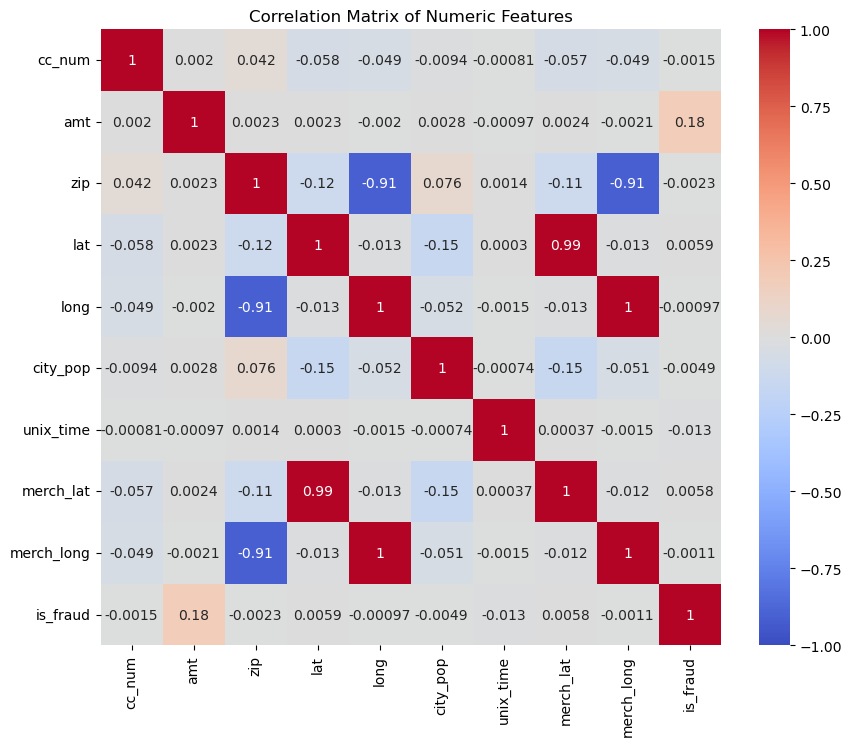

In [65]:
# Select only numeric columns (float and int)
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Calculate correlation matrix
correlation_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

AttributeError: 'NoneType' object has no attribute 'to_string'

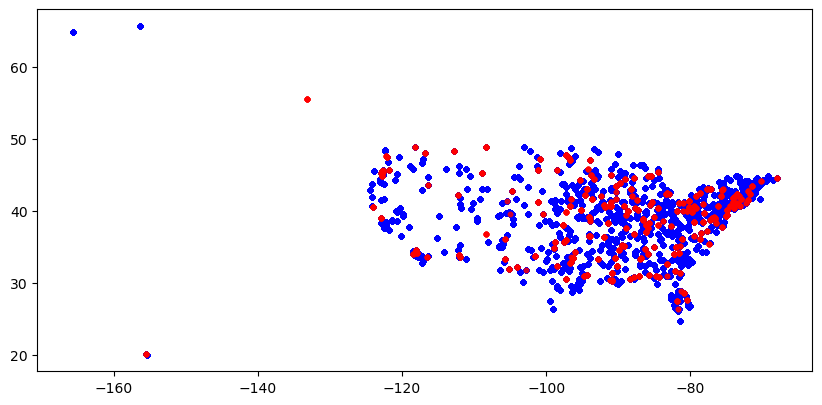

In [98]:
import geopandas as gpd
import contextily as ctx

# Convert DataFrame to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.long, df.lat))

# Plot the data
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf[gdf['is_fraud'] == 0].plot(ax=ax, markersize=10, color='blue', alpha=0.5, label='Non-Fraud')
gdf[gdf['is_fraud'] == 1].plot(ax=ax, markersize=10, color='red', alpha=0.5, label='Fraud')

# Add basemap
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Stamen.TonerLite)

plt.title('Fraud by Location on Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()